# CONFORMAL ANALYSIS NOTEBOOK
_________________________



## Imports and Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])


from src.conformal.pipeline import run_mondrian_regression






cwd: /home/victor/gw/cbc_pe/notebooks
sys.path: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '']


In [2]:
# Function to generate synthetic data



def make_synthetic_regression_data(n_cal, n_test, rng=None):
    
    y_cal = np.column_stack([
        rng.normal(loc=25.0, scale=5.0, size=n_cal),    # chirp-like
        rng.normal(loc=60.0, scale=10.0, size=n_cal),   # total-mass-like
        rng.normal(loc=0.0, scale=0.3, size=n_cal),     # chi_eff-like
    ])

    # Heteroscedastic noise: error depends a bit on the true value
    cal_noise = np.column_stack([
        rng.normal(0.0, 0.8 + 0.03 * np.abs(y_cal[:, 0]), size=n_cal),
        rng.normal(0.0, 1.5 + 0.02 * np.abs(y_cal[:, 1]), size=n_cal),
        rng.normal(0.0, 0.05 + 0.10 * np.abs(y_cal[:, 2]), size=n_cal),
    ])

    # Predictions are truth plus noise
    pred_cal = y_cal + cal_noise

    # Residuals in the convention y_true - y_pred
    residuals_cal = y_cal - pred_cal

    # Test data
    y_test = np.column_stack([
        rng.normal(loc=25.0, scale=5.0, size=n_test),
        rng.normal(loc=60.0, scale=10.0, size=n_test),
        rng.normal(loc=0.0, scale=0.3, size=n_test),
    ])

    test_noise = np.column_stack([
        rng.normal(0.0, 0.8 + 0.03 * np.abs(y_test[:, 0]), size=n_test),
        rng.normal(0.0, 1.5 + 0.02 * np.abs(y_test[:, 1]), size=n_test),
        rng.normal(0.0, 0.05 + 0.10 * np.abs(y_test[:, 2]), size=n_test),
    ])

    pred_test = y_test + test_noise


    return pred_cal, y_cal, pred_test, y_test




In [3]:
# Generate synthetic data
n_cal = 400
n_test = 200

rng = np.random.default_rng(42)
pred_cal, y_cal, pred_test, y_test = make_synthetic_regression_data(n_cal=n_cal, n_test=n_test, rng=rng)

## Legacy implementation (not supported)

In [4]:


results = run_mondrian_regression(
        pred_cal=pred_cal,
        pred_test=pred_test, 
        y_cal=y_cal, 
        y_test=y_test,
        n_bins=6,
        confidence_level=0.90,
        apply_jitter=True,
    )

print("Global coverage:", results.metrics["global_coverage"])
print("Global mean width:", results.metrics["global_mean_width"])
print("Coverage per bin:\n", results.metrics["coverage_per_bin"])
print("Counts per bin:\n", results.metrics["counts_per_bin"])





Global coverage: [0.965 0.92  0.915]
Global mean width: [5.74982542 9.38491207 0.28089402]
Coverage per bin:
 [[0.96551724 0.89473684 0.8       ]
 [1.         0.97674419 0.96153846]
 [0.94871795 0.90697674 0.88571429]
 [0.97058824 0.96969697 1.        ]
 [0.96153846 0.875      0.96428571]
 [0.95833333 0.86842105 0.93333333]]
Counts per bin:
 [[29 19 40]
 [24 43 26]
 [39 43 35]
 [34 33 26]
 [26 24 28]
 [48 38 45]]


A function to run the conformal mondrian for diferent grid sized (n_bins)

In [5]:
import pandas as pd

def evaluate_bins_grid(pred_cal, y_cal, pred_test, y_test, bins_list, confidence_level=0.90, apply_jitter=True):
    rows = []
    results_dict = {}

    for n_bins in bins_list:
        res = run_mondrian_regression(
            pred_cal=pred_cal,
            pred_test=pred_test,
            y_cal=y_cal,
            y_test=y_test,
            n_bins=n_bins,
            confidence_level=confidence_level,
            apply_jitter=apply_jitter,
        )
        results_dict[n_bins] = res

        metrics = res.metrics
        cov = metrics["global_coverage"]
        width = metrics["global_mean_width"]
        cov_bin = metrics["coverage_per_bin"]
        counts = metrics["counts_per_bin"]

        row = {
            "n_bins": n_bins,
            "cov_M_chirp": cov[0],
            "cov_M_total": cov[1],
            "cov_chi_eff": cov[2],
            "width_M_chirp": width[0],
            "width_M_total": width[1],
            "width_chi_eff": width[2],
            "min_count": np.nanmin(counts),
            "max_count": np.nanmax(counts),
            "min_cov_bin_M_chirp": np.nanmin(cov_bin[:, 0]),
            "min_cov_bin_M_total": np.nanmin(cov_bin[:, 1]),
            "min_cov_bin_chi_eff": np.nanmin(cov_bin[:, 2]),
        }
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    return summary_df, results_dict

To visualize some metrics for different sizes.

In [6]:
bins_list = [3, 6, 12, 24]
summary_df, results_dict = evaluate_bins_grid(
    pred_cal=pred_cal,
    y_cal=y_cal,
    pred_test=pred_test,
    y_test=y_test,
    bins_list=bins_list,
    confidence_level=0.90,
    apply_jitter=True,
)

summary_df

,n_bins,cov_M_chirp,cov_M_total,cov_chi_eff,width_M_chirp,width_M_total,width_chi_eff,min_count,max_count,min_cov_bin_M_chirp,min_cov_bin_M_total,min_cov_bin_chi_eff
0,3,0.940,0.905,0.895,5.546234,8.666441,0.260241,53,76,0.918919,0.870968,0.848485
1,6,0.965,0.920,0.915,5.749825,9.384912,0.280894,19,48,0.948718,0.868421,0.800000
2,12,0.960,0.915,0.920,5.752896,9.514221,0.292070,8,29,0.888889,0.809524,0.750000
3,24,0.965,0.945,0.965,7.150889,11.073646,0.336557,1,20,0.666667,0.727273,0.818182


- In general, the coverage for $M_{chirp}$ is too much conservative, above 90%. Increasing the number of bins also increases the global coverage, although the miniminum coverage (i.e. in a bin) goes from 91.9% for low n_bins to 88.9% for high n_bins. The global widht barely changes with a slighly rise when n_bins grows.
- Other variables such as $M_{total}$ or $\chi_{eff}$ have a more reasonable global coverage around the exepected (C.L. ~ 90%). Their width also suffer a more notable grow with n_bins. Additionally, for this variables the minimun coverage is widely under the 90% with remarks the reasonable fluctuations of coverage for differents bins, which could be the result of better and worst regions for the regression of the variables.

### Coverage/Mean-Width Plots  

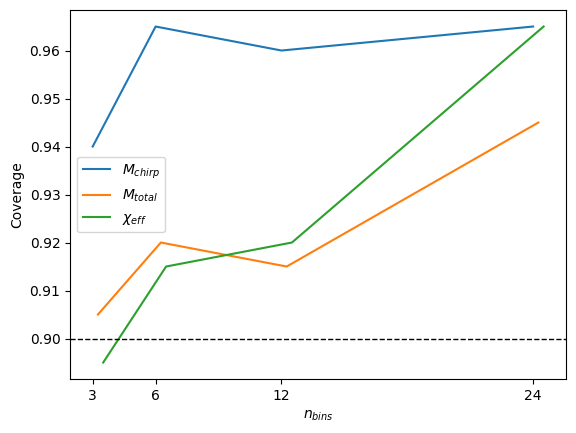

In [7]:
# Plot of global coverage vs n_bins

import matplotlib.pyplot as plt

plt.plot(summary_df["n_bins"], summary_df["cov_M_chirp"], label="$M_{chirp}$")
plt.plot(summary_df["n_bins"]+0.25, summary_df["cov_M_total"], label="$M_{total}$")
plt.plot(summary_df["n_bins"]+0.5, summary_df["cov_chi_eff"], label="$\\chi_{eff}$")
plt.axhline(0.90, color='black', linestyle='--', linewidth=1)
plt.xlabel("$n_{bins}$")
plt.ylabel("Coverage")
plt.xticks(summary_df["n_bins"])
plt.legend()
plt.show()

# Also plot an histogram instead of a scatter with the three metrics in the same plot for each n_bins

#plt.hist(summary_df["cov_M_chirp"], bins = 4, alpha=0.5, label="$M_{chirp}$")




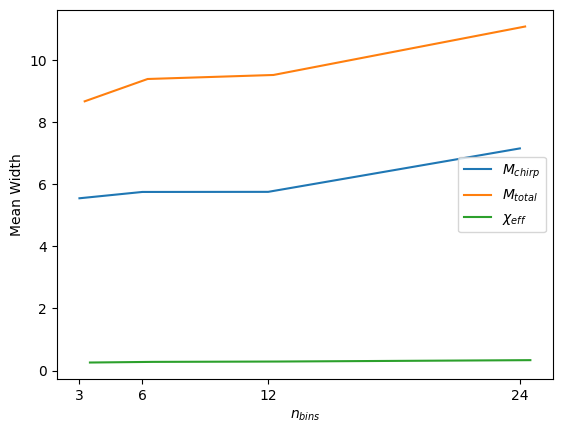

In [8]:

#Plot also the scatter for the mean width vs n_bins

plt.plot(summary_df["n_bins"], summary_df["width_M_chirp"], label="$M_{chirp}$")
plt.plot(summary_df["n_bins"]+0.25, summary_df["width_M_total"], label="$M_{total}$")
plt.plot(summary_df["n_bins"]+0.5, summary_df["width_chi_eff"], label="$\\chi_{eff}$")
plt.xlabel("$n_{bins}$")
plt.ylabel("Mean Width")
plt.xticks(summary_df["n_bins"])
plt.legend()
plt.show()

[[0.96551724 0.89473684 0.8       ]
 [1.         0.97674419 0.96153846]
 [0.94871795 0.90697674 0.88571429]
 [0.97058824 0.96969697 1.        ]
 [0.96153846 0.875      0.96428571]
 [0.95833333 0.86842105 0.93333333]]
[[29 19 40]
 [24 43 26]
 [39 43 35]
 [34 33 26]
 [26 24 28]
 [48 38 45]]


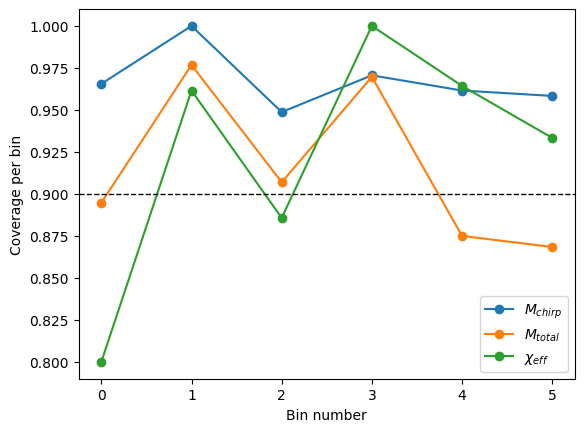

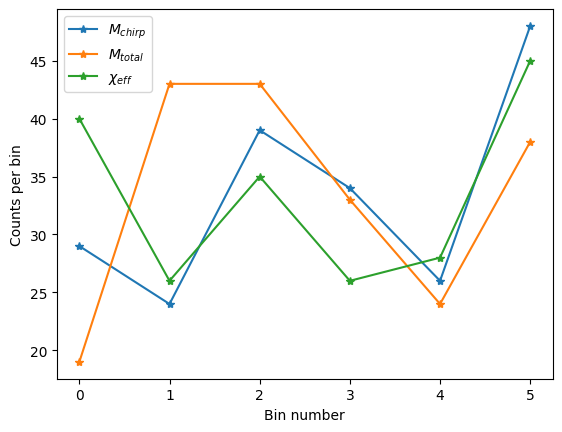

In [9]:
n_bins = 6
#summary_df.keys()
results_dict.keys()
cov_bin = results_dict[n_bins].metrics["coverage_per_bin"]
counts_bin = results_dict[n_bins].metrics["counts_per_bin"]

print(cov_bin)
print(counts_bin)
labels = ["$M_{chirp}$", "$M_{total}$", "$\\chi_{eff}$"]

for i, label in zip(range(cov_bin.shape[1]), labels):
    plt.plot(np.arange(n_bins), cov_bin[:, i], marker="o", label=label)

plt.axhline(0.90, color='black', linestyle='--', linewidth=1)
plt.xlabel("Bin number")
plt.ylabel("Coverage per bin")
plt.xticks(np.arange(n_bins))
plt.legend()
plt.show()

for i, label in zip(range(counts_bin.shape[1]), labels):
    plt.plot(np.arange(n_bins), counts_bin[:, i], marker="*", label=label)


plt.xlabel("Bin number")
plt.ylabel("Counts per bin")
plt.xticks(np.arange(n_bins))
plt.legend()
plt.show()




### With vs Without `apply_jitter`

In [10]:
bins_list = [3, 6, 12, 24]

summary_df_jitter, results_dict_jitter = evaluate_bins_grid(
    pred_cal=pred_cal,
    y_cal=y_cal,
    pred_test=pred_test,
    y_test=y_test,
    bins_list=bins_list,
    confidence_level=0.90,
    apply_jitter=True,
)

summary_df_no_jitter, results_dict_no_jitter = evaluate_bins_grid(
    pred_cal=pred_cal,
    y_cal=y_cal,
    pred_test=pred_test,
    y_test=y_test,
    bins_list=bins_list,
    confidence_level=0.90,
    apply_jitter=False,
)



/tmp/ipykernel_139083/2479188972.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


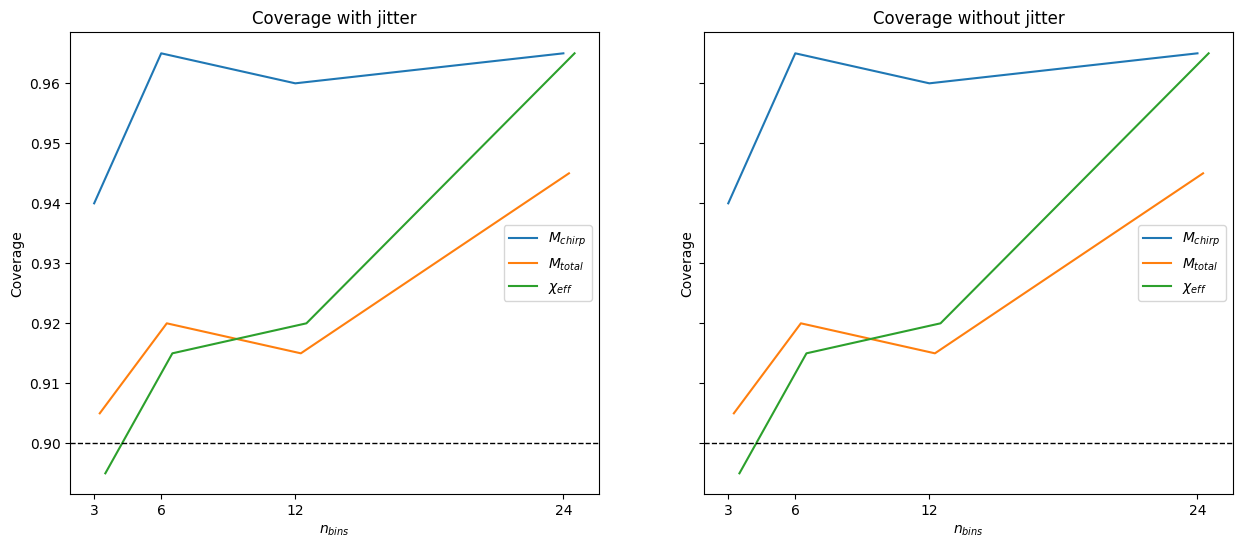

In [11]:
import matplotlib.pyplot as plt

fig, [ax1, ax2] = plt.subplots(1, 2, sharey=True, figsize=(15,6))
ax1.plot(summary_df_jitter["n_bins"], summary_df_jitter["cov_M_chirp"], label="$M_{chirp}$")
ax1.plot(summary_df_jitter["n_bins"]+0.25, summary_df_jitter["cov_M_total"], label="$M_{total}$")
ax1.plot(summary_df_jitter["n_bins"]+0.5, summary_df_jitter["cov_chi_eff"], label="$\\chi_{eff}$")
ax1.axhline(0.90, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel("$n_{bins}$")
ax1.set_ylabel("Coverage")
ax1.set_xticks(summary_df_jitter["n_bins"])
ax1.set_title("Coverage with jitter")
ax1.legend()



ax2.plot(summary_df_no_jitter["n_bins"], summary_df_no_jitter["cov_M_chirp"], label="$M_{chirp}$")
ax2.plot(summary_df_no_jitter["n_bins"]+0.25, summary_df_no_jitter["cov_M_total"], label="$M_{total}$")
ax2.plot(summary_df_no_jitter["n_bins"]+0.5, summary_df_no_jitter["cov_chi_eff"], label="$\\chi_{eff}$")
ax2.axhline(0.90, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel("$n_{bins}$")
ax2.set_ylabel("Coverage")
ax2.set_xticks(summary_df_no_jitter["n_bins"])
ax2.set_title("Coverage without jitter")
ax2.legend()

fig.show()

/tmp/ipykernel_139083/1940246074.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


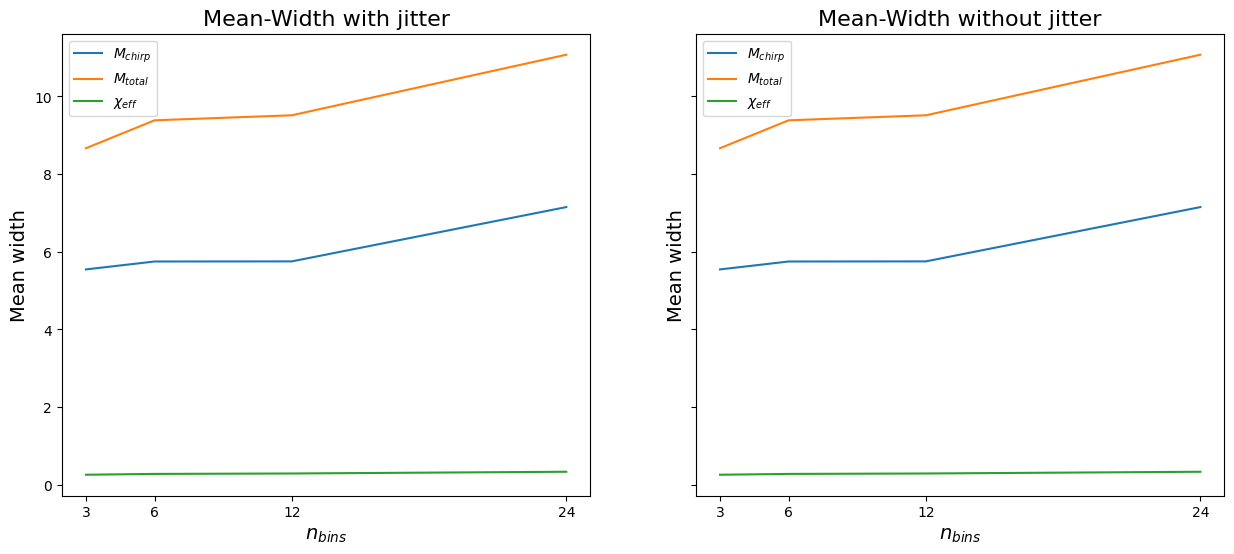

In [12]:
fig, [ax1, ax2] = plt.subplots(1, 2, sharey=True, figsize=(15,6))
ax1.plot(summary_df_jitter["n_bins"], summary_df_jitter["width_M_chirp"], label="$M_{chirp}$")
ax1.plot(summary_df_jitter["n_bins"], summary_df_jitter["width_M_total"], label="$M_{total}$")
ax1.plot(summary_df_jitter["n_bins"], summary_df_jitter["width_chi_eff"], label="$\\chi_{eff}$")
ax1.set_xlabel("$n_{bins}$",  size=14)
ax1.set_ylabel("Mean width",  size=14)
ax1.set_xticks(summary_df_jitter["n_bins"])
ax1.set_title("Mean-Width with jitter",  size=16)
ax1.legend()



ax2.plot(summary_df_no_jitter["n_bins"], summary_df_no_jitter["width_M_chirp"], label="$M_{chirp}$")
ax2.plot(summary_df_no_jitter["n_bins"], summary_df_no_jitter["width_M_total"], label="$M_{total}$")
ax2.plot(summary_df_no_jitter["n_bins"], summary_df_no_jitter["width_chi_eff"], label="$\\chi_{eff}$")
#ax2.set_yscale("log")
ax2.set_xlabel("$n_{bins}$",  size=14)
ax2.set_ylabel("Mean width", size=14)
ax2.set_xticks(summary_df_no_jitter["n_bins"])
ax2.set_title("Mean-Width without jitter", size=16 )
ax2.legend()

fig.show()

¿Is there any quantity to measure the goodness of the bin choice? Like some sort of $\eta=\frac{mean-width}{coverage}$, which takes low values for the best choice of number of bins.

- With low number of bins the coverage is closer to the C.L., however when the bins increased so does the coverage towards a value of one. This behaviour is expected as the consequence of the a larger mean width with the number of bins, i.e., larger widths implies a more conservative interval, and therefore more samples fall into the coverage region.

In [92]:
import numpy as np

n_samples = 2
k = 5
n_labels = 3

res = np.random.random([2,5,3])*10
w =  np.random.random([2,5])*2
print(res.shape)
#print(res)

print("\n",w.shape)
#print("w", w)

# We want to add a new axis to w so that we can multiply it with res, which has shape (2,5,3). We want w to have shape (2,5,1) so that it can be broadcasted to (2,5,3).
new_res = w.reshape(-1,5,1)
print("\n", new_res.shape)


#print("new_res", new_res)

print("multiplication", new_res * res)
print("multiplication shape", (new_res * res).shape)


print("sum over axis 1", np.sum(new_res * res, axis=1))
print("sum over axis 1 shape", np.sum(new_res * res, axis=1).shape)

print("sum of weights", np.sum(w, axis=1))
print("sum of weights shape", np.sum(w, axis=1)[:, np.newaxis].shape)

print("final division", np.sum(new_res * res, axis=1) / np.sum(w, axis=1)[:, np.newaxis])

(2, 5, 3)

 (2, 5)

 (2, 5, 1)
multiplication [[[7.27682011e+00 4.60397282e-03 3.54010173e+00]
  [9.76505233e+00 3.65936895e+00 1.04983920e+01]
  [6.12994850e+00 2.86851557e+00 1.26526637e+01]
  [1.24262717e+00 1.20799145e+01 8.25896665e+00]
  [8.09188575e-01 4.79557871e-01 1.70628946e-01]]

 [[8.08214862e+00 1.12940197e+01 1.01488071e+01]
  [3.66795064e+00 6.49866813e+00 1.16773806e+00]
  [7.50897433e+00 2.63707086e+00 5.42662627e+00]
  [1.64954576e+01 9.73873335e+00 8.33028826e+00]
  [2.95761966e-01 7.54164437e+00 5.54708539e+00]]]
multiplication shape (2, 5, 3)
sum over axis 1 [[25.22363668 19.09196087 35.120753  ]
 [36.05029314 37.71013638 30.62054509]]
sum over axis 1 shape (2, 3)
sum of weights [5.05711256 7.41719838]
sum of weights shape (2, 1)
final division [[4.98775465 3.77526912 6.94482327]
 [4.86036523 5.08414828 4.12831685]]


In [14]:
from scipy.stats import iqr

a = np.array([[1,2,3], [4,5,6], [9,8,7]])


q1 = np.quantile(a, q=0.25, axis=0)
q2 = np.quantile(a, q=0.5, axis=0)
q3 = np.quantile(a, q=0.75, axis=0)


np_iqr = q3 - q1
scipy_iqr = iqr(a, axis=0)

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)
print("Numpy IQR:", np_iqr)
print("Scipy IQR:", scipy_iqr)



Q1: [2.5 3.5 4.5]
Q2: [4. 5. 6.]
Q3: [6.5 6.5 6.5]
Numpy IQR: [4. 3. 2.]
Scipy IQR: [4. 3. 2.]


____
# CONFORMAL ANALYSIS (VERSION 1.0)

- As first approach we only consider the ``taxonomy_mode = "prediction"``.
- A comparation between  the mode ``symmetric`` and ``asymmetric`` for the intervals is performed.
- Also, the number of bins is analyzed for a range of ``n_bins = [3, 6, 12, 24, 48]``. 

## Metrics

In [69]:
from scipy.stats import iqr
import numpy as np
import pandas as pd

rows = []
all_results = {}

for n in n_bins:
    for interval_mode in interval_modes:

        results = run_mondrian_regression(
            pred_cal=pred_cal,
            pred_test=pred_test, 
            y_cal=y_cal, 
            y_test=y_test,
            n_bins=n,
            confidence_level=0.90,
            apply_jitter=True,
            interval_mode=interval_mode,
            taxonomy_mode=taxonomy_mode,
        )

        all_results[(n, interval_mode)] = results



        metrics = results.metrics
        intervals = results.intervals

        # intervals shape assumed: (n_samples, n_labels, 2)
        widths = intervals[:, :, 1] - intervals[:, :, 0]
        

        for i, label_name in enumerate(label_names):
            row = {
                "n_bins": n,
                "interval_mode": interval_mode,
                "taxonomy_mode": taxonomy_mode,
                "label": label_name,

                "global_coverage": metrics["global_coverage"][i],
                "global_mean_width": metrics["global_mean_width"][i],
                "global_median_width": metrics["global_median_width"][i],

                "width_median": np.nanmedian(widths[:, i]),
                "width_mean": np.nanmean(widths[:, i]),
                "width_iqr": iqr(widths, axis=1, nan_policy="omit")[i],

                "max_undercoverage_gap": metrics["max_undercoverage_gap"][i],
                "min_cov_bin": np.nanmin(metrics["coverage_per_bin"][:, i]),
                "mean_cov_bin": np.nanmean(metrics["coverage_per_bin"][:, i]),
                "max_cov_bin": np.nanmax(metrics["coverage_per_bin"][:, i]),
            }
            
            

            rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv("summary.csv")
summary_df

,n_bins,interval_mode,taxonomy_mode,label,global_coverage,global_mean_width,global_median_width,width_median,width_mean,width_iqr,max_undercoverage_gap,min_cov_bin,mean_cov_bin,max_cov_bin
0,3,symmetric,prediction,M_chirp,0.940,5.546234,5.602148,5.602148,5.008726,0.136428,0.000000,0.918919,0.943853,0.981132
1,3,symmetric,prediction,M_total,0.905,8.666441,8.722205,5.388718,4.776624,0.522945,0.029032,0.870968,0.902801,0.934211
2,3,symmetric,prediction,chi_eff,0.895,0.260241,0.268822,5.661575,4.685961,0.034021,0.051515,0.848485,0.895674,0.934426
3,3,asymmetric,prediction,M_chirp,0.945,5.451262,5.304051,5.076970,4.494752,0.393794,0.000000,0.918919,0.946696,0.962264
4,3,asymmetric,prediction,M_total,0.910,8.649736,8.294528,5.304051,4.955167,0.617161,0.029032,0.870968,0.906197,0.960526
5,3,asymmetric,prediction,chi_eff,0.875,0.251100,0.271744,5.864557,4.810276,0.040079,0.051515,0.848485,0.874714,0.890411
6,6,symmetric,prediction,M_chirp,0.965,5.749825,5.813218,5.204508,4.965382,0.875180,0.000000,0.948718,0.967449,1.000000
7,6,symmetric,prediction,M_total,0.920,9.384912,9.267252,6.320867,5.691146,0.886810,0.031579,0.868421,0.915263,0.976744
8,6,symmetric,prediction,chi_eff,0.915,0.280894,0.286989,5.813218,4.920113,0.058875,0.100000,0.800000,0.924145,1.000000
9,6,asymmetric,prediction,M_chirp,0.950,5.490235,5.856847,4.434368,3.864859,1.057661,0.037931,0.862069,0.949579,1.000000


Puedo incluir otras variables como:
1. Dispersion del width por bin para cada label (uno por bin). Mide cuanto cambia la anchura del intervalo entre unas regiones y otras de la taxonomia. Es relevante para el caso en el que tenga dos configuraciones con la misma anchura global mediana/media, pero
    - u una reparte anchuras de forma razonablemente estable;
    - otra tiene bins con intervalos muy estrechos y otros absurdamente grandes.

    Puesto que solo se tiene una medida por bin (no hay muchos puntos) se podría medir el IQR o rango, ya que la desviación estándar es más dificil de interpretar.

    *Interpretación*
    - dispersión baja: las anchuras son bastante uniformes entre bins
    - dispersión alta: la taxonomía está adaptando mucho la anchura según región

    Aunque cuidado, porque dispersión alta no es automáticamente mala. Puede estar bien si refleja heterogeneidad real del problema. Se vuelve vuelve conflictiva si, 
    - viene acompañada de bins muy pequeños,
    - de intervalos gigantes en ciertas zonas,
    - de undercoverage en otras.

    Por eso mejor usar como métrica diagnóstica, no como criterio principal de selección.



## Coverture Tolerance for several configurations

In [16]:

CL = 0.90 # Confidence level for the tolerance intervals
counts = metrics["counts_per_bin"] # We can compute the global coverage as the total number of covered samples across all bins divided by the total number of samples. This is a more accurate way to compute the global coverage, especially if the bins have different numbers of samples.

n_samples = np.sum(counts, axis=0)[0] # We take the total number of samples across all bins for the first label, but ideally this should be taken from the actual data used in the evaluation.
print("n", n_samples)


global_coverage_tolerance = 2 * np.sqrt(CL* (1 - CL) / 200) # Normal approximation for binomial proportion confidence interval
tolerance_interval = (CL - global_coverage_tolerance, CL + global_coverage_tolerance)
print(f"\tGlobal coverage tolerance : [{global_coverage_tolerance:.3f}]")

for configuration in summary_df.itertuples():
    print("\nConfiguration: n_bins={}, interval_mode={}, label={}".format(configuration.n_bins, configuration.interval_mode, configuration.label))
    print(f"\tGlobal coverage: {configuration.global_coverage:.3f}")

    
    print(f"\tGlobal coverage tolerance interval: [{tolerance_interval[0]:.3f}, {tolerance_interval[1]:.3f}]")
    print(f"\tIs the global coverage within the tolerance interval? {'Yes' if tolerance_interval[0] <= configuration.global_coverage <= tolerance_interval[1] else 'No'}")

n 200
	Global coverage tolerance : [0.042]

Configuration: n_bins=3, interval_mode=symmetric, label=M_chirp
	Global coverage: 0.940
	Global coverage tolerance interval: [0.858, 0.942]
	Is the global coverage within the tolerance interval? Yes

Configuration: n_bins=3, interval_mode=symmetric, label=M_total
	Global coverage: 0.905
	Global coverage tolerance interval: [0.858, 0.942]
	Is the global coverage within the tolerance interval? Yes

Configuration: n_bins=3, interval_mode=symmetric, label=chi_eff
	Global coverage: 0.895
	Global coverage tolerance interval: [0.858, 0.942]
	Is the global coverage within the tolerance interval? Yes

Configuration: n_bins=3, interval_mode=asymmetric, label=M_chirp
	Global coverage: 0.945
	Global coverage tolerance interval: [0.858, 0.942]
	Is the global coverage within the tolerance interval? No

Configuration: n_bins=3, interval_mode=asymmetric, label=M_total
	Global coverage: 0.910
	Global coverage tolerance interval: [0.858, 0.942]
	Is the global 

 _______________________________________________________________________
##  Some Plots

In [17]:
import matplotlib.pyplot as plt

plot_labels = {
    "M_chirp": "$M_{chirp}$",
    "M_total": "$M_{total}$",
    "chi_eff": "$\\chi_{eff}$",
}

color_map = {
    "symmetric": "teal",
    "asymmetric": "peru",
}

### Global Coverage

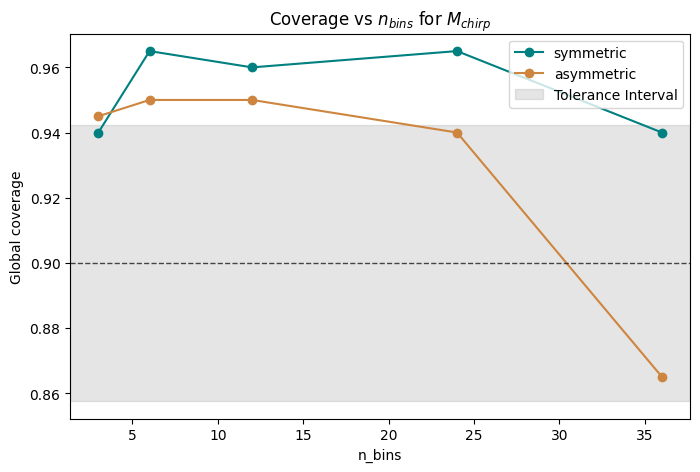

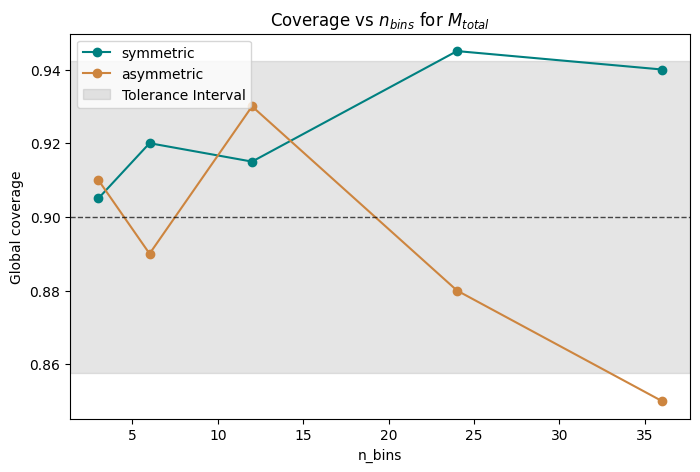

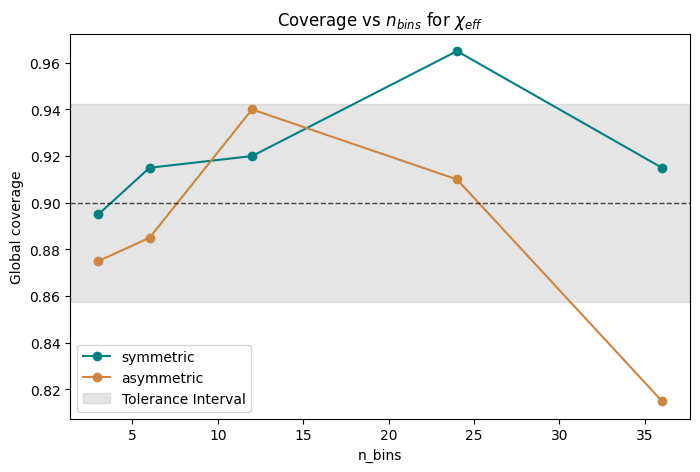

In [18]:


for label_name in label_names:
    df_label = summary_df[summary_df["label"] == label_name].sort_values("n_bins")

    plt.figure(figsize=(8, 5))

    for interval_mode in interval_modes:
        df_mode = df_label[df_label["interval_mode"] == interval_mode]
        plt.plot(
            df_mode["n_bins"],
            df_mode["global_coverage"],
            color=color_map[interval_mode],
            marker="o",
            label=interval_mode,
        )

    plt.axhline(0.90, linestyle="--", linewidth=1, color='black', alpha=0.7)
    plt.axhspan(0.90 - global_coverage_tolerance, 0.90 + global_coverage_tolerance, color='gray', alpha=0.2, label="Tolerance Interval")
    plt.xlabel("n_bins")
    plt.ylabel("Global coverage")
    plt.title(f"Coverage vs $n_{{bins}}$ for {plot_labels[label_name]}")
    plt.legend()
    plt.show()

### Global median width

In [ ]:
for label_name in label_names:
    df_label = summary_df[summary_df["label"] == label_name].sort_values("n_bins")

    plt.figure(figsize=(8, 5))

    for interval_mode in interval_modes:
        df_mode = df_label[df_label["interval_mode"] == interval_mode]
        plt.plot(
            df_mode["n_bins"],
            df_mode["global_median_width"],
            color=color_map[interval_mode],
            marker="o",
            label=interval_mode,
        )

    plt.xlabel("n_bins")
    plt.ylabel("Global median width")
    plt.title(f"Median width vs $n_{{bins}}$ for {plot_labels.get(label_name, label_name)}")
    plt.legend()
    plt.show()

### Global mean width

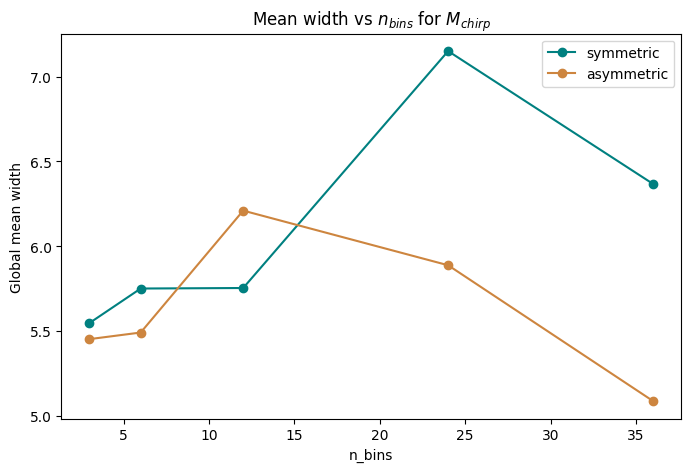

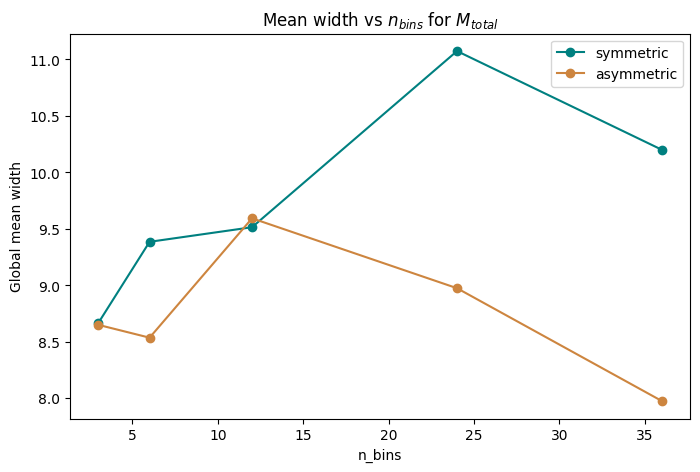

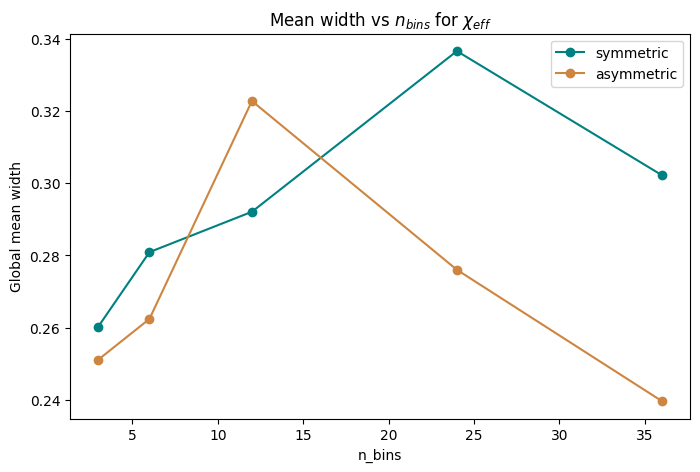

In [ ]:
for label_name in label_names:
    df_label = summary_df[summary_df["label"] == label_name].sort_values("n_bins")

    plt.figure(figsize=(8, 5))

    for interval_mode in interval_modes:
        df_mode = df_label[df_label["interval_mode"] == interval_mode]
        plt.plot(
            df_mode["n_bins"],
            df_mode["global_mean_width"],
            color=color_map[interval_mode],
            marker="o",
            label=interval_mode,
        )

    plt.xlabel("n_bins")
    plt.ylabel("Global mean width")
    plt.title(f"Mean width vs $n_{{bins}}$ for {plot_labels.get(label_name, label_name)}")
    plt.legend()
    plt.show()

### Width dispersion

As a way to measure the dispersion of the widths (upper - lower) between different configurations. However, due to the low number of widths (one per bin), a more reasonable way to interpret the spread is to used the IQR (interquartile range). This is the range between the 25th and 75th percentile.


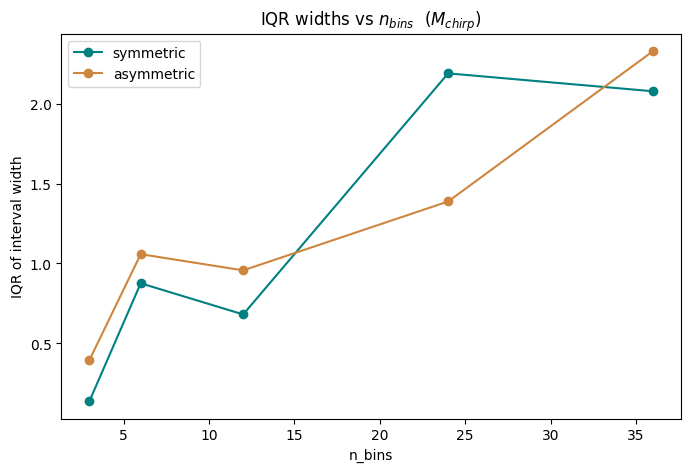

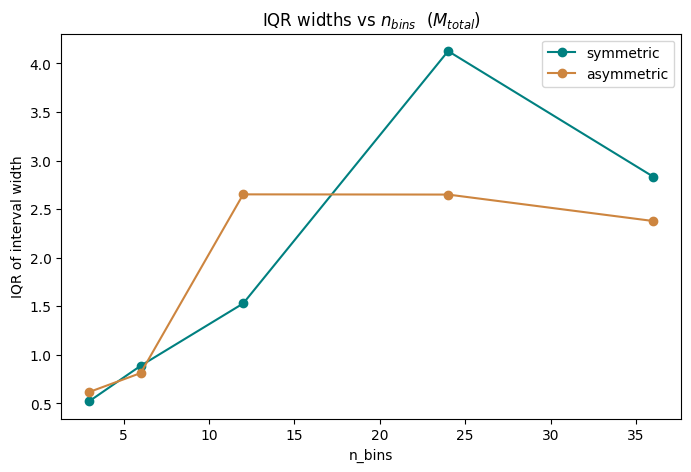

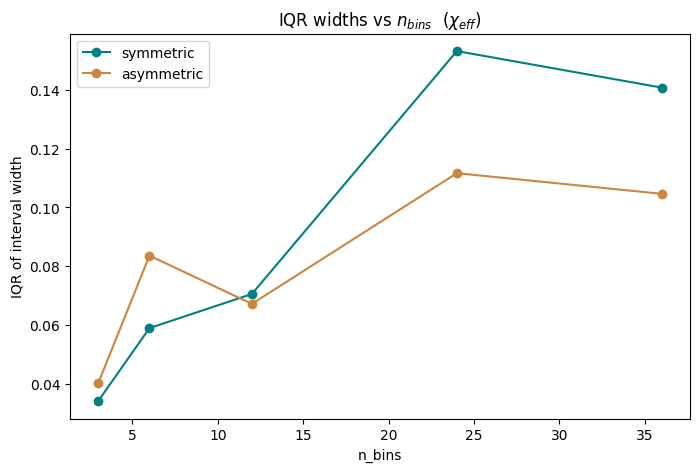

In [72]:
import matplotlib.pyplot as plt

for label_name in label_names:
    df_label = summary_df[
        summary_df["label"] == label_name
    ].sort_values("n_bins")

    plt.figure(figsize=(8, 5))

    for interval_mode in interval_modes:
        df_mode = df_label[df_label["interval_mode"] == interval_mode]

        plt.plot(
            df_mode["n_bins"],
            df_mode["width_iqr"],
            color=color_map[interval_mode],
            marker="o",
            label=interval_mode,
        )

    plt.xlabel("n_bins")
    plt.ylabel("IQR of interval width")
    plt.title(f"IQR widths vs $n_{{bins}}$  ({plot_labels.get(label_name, label_name)})")
    plt.legend()
    plt.show()

### Counts variation 

To study the variation in the number of samples in the bins (as some prove of stability), we compute the following parameter: $$\mathcal{R}=\frac{n_{max} - n_{min}}{n_{max} + n_{min}}$$

Where $n_{max}$ and $n_{min}$ are the maximum and minimum number of samples in the bins for each configuracion of the number of bins. The 'normalization' is done to reduce the the effect of the the bins with maximun/minimun counts accross configuracions.

n_bins: 3
ratio: [0.16535433 0.10144928 0.08955224]
n_bins: 6
ratio: [0.33333333 0.38709677 0.26760563]
n_bins: 12
ratio: [0.52631579 0.48387097 0.54285714]
n_bins: 24
ratio: [0.8       0.875     0.9047619]
n_bins: 36
ratio: [0.73333333 0.85714286 1.        ]


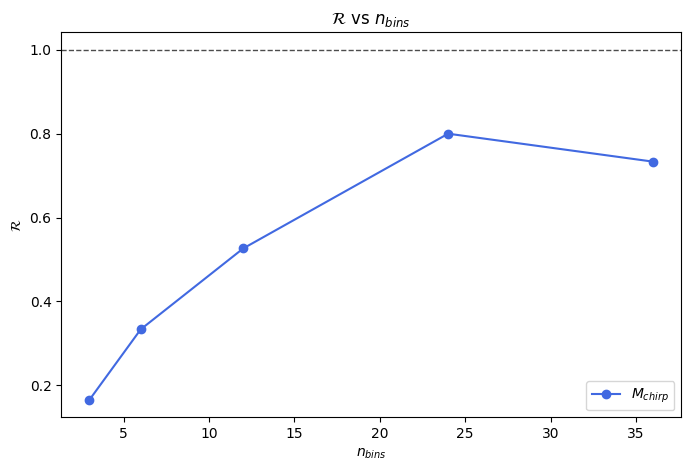

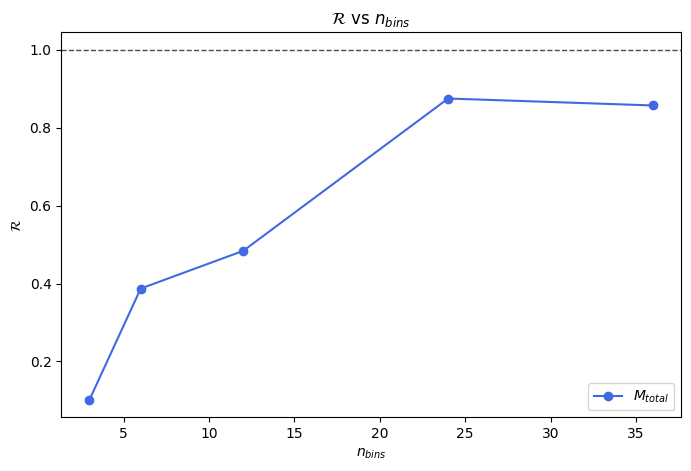

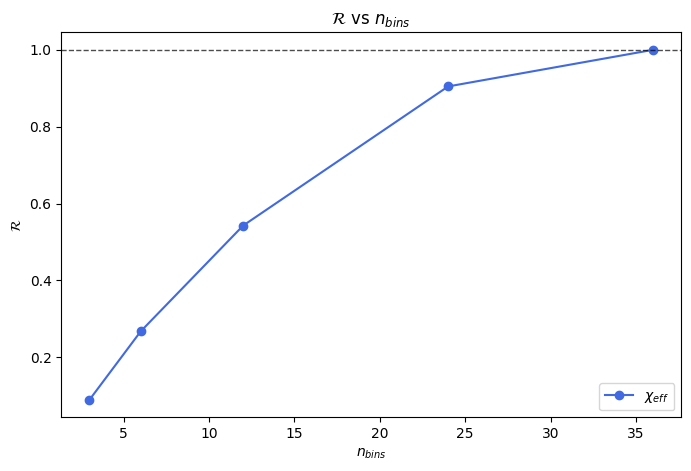

In [22]:
difference_max_min = []
sum_max_min = []
ratio_max_min = []

for key,result in all_results.items():
    if key[1] == "symmetric":
        counts_per_bin = result.metrics['counts_per_bin']
        print(f"n_bins: {key[0]}")
        #print(f"counts_per_bin: {counts_per_bin}")
        max_counts = np.max(counts_per_bin, axis=0)
        min_counts = np.min(counts_per_bin, axis=0)
        difference = max_counts - min_counts
        ratio = difference / (max_counts + min_counts)

        print(f"ratio: {ratio}")
        difference_max_min.append(difference)
        sum_max_min.append(max_counts + min_counts)
        ratio_max_min.append(ratio)

ratio_max_min = np.array(ratio_max_min)
#print(ratio_max_min)


#Plot the ratios for each number of bins

for i,  label_name in enumerate(label_names):
    df_label = summary_df[summary_df["label"] == label_name].sort_values("n_bins")

    plt.figure(figsize=(8, 5))

    plt.plot(
        n_bins,
        ratio_max_min[:, i],
        color="royalblue",
        marker="o",
        label=plot_labels[label_name],
    )
    plt.axhline(1, linestyle="--", linewidth=1, color='black', alpha=0.7)
    plt.xlabel(f"$n_{{bins}}$")
    plt.ylabel(r"$\mathcal{{R}}$")
    plt.title(rf"$\mathcal{{R}}$ vs $n_{{bins}}$")
    plt.legend()
    plt.show()



     

In [23]:
#plot the 

### Counts per bin dispersion (IQR)

In [24]:
from scipy.stats import iqr
import numpy as np

difference_max_min = []
sum_max_min = []
ratio_max_min = []

for key,result in all_results.items():
    if key[1] == "symmetric":
        counts_per_bin = result.metrics['counts_per_bin']
        print(f"n_bins: {key[0]}")
        print(f"counts_per_bin: {counts_per_bin}")
        print(f"IQR counts_per_bin: {iqr(counts_per_bin)}")
        

# No es muy buena idea comparar porque n_bins bajos tendra mucho y a medida que crece el n_bins, el iqr es mas pequeño claramente



n_bins: 3
counts_per_bin: [[53 62 66]
 [73 76 61]
 [74 62 73]]
IQR counts_per_bin: 11.0
n_bins: 6
counts_per_bin: [[29 19 40]
 [24 43 26]
 [39 43 35]
 [34 33 26]
 [26 24 28]
 [48 38 45]]
IQR counts_per_bin: 13.75
n_bins: 12
counts_per_bin: [[17 11 16]
 [12  8 24]
 [14 20 18]
 [10 23  8]
 [25 21 12]
 [14 22 23]
 [ 9 17  8]
 [25 16 18]
 [13  9 12]
 [13 15 16]
 [19 21 18]
 [29 17 27]]
IQR counts_per_bin: 9.0
n_bins: 24
counts_per_bin: [[12  6  8]
 [ 5  5  8]
 [ 8  4 13]
 [ 4  4 11]
 [ 8 13  7]
 [ 6  7 11]
 [ 3  8  3]
 [ 7 15  5]
 [ 7  8  9]
 [18 13  3]
 [ 8 11 10]
 [ 6 11 13]
 [ 2  9  7]
 [ 7  8  1]
 [15  7 11]
 [10  9  7]
 [10  3  7]
 [ 3  6  5]
 [ 4  1  9]
 [ 9 14  7]
 [ 9  8  7]
 [10 13 11]
 [14 12  7]
 [15  5 20]]
IQR counts_per_bin: 5.0
n_bins: 36
counts_per_bin: [[12  1  3]
 [ 3  7  6]
 [ 2  3  7]
 [ 4  3 10]
 [ 6  4  7]
 [ 2  1  7]
 [ 8 13  6]
 [ 4  1  4]
 [ 2  6  8]
 [ 2  6  2]
 [ 6  5  2]
 [ 2 12  4]
 [ 5  5  9]
 [ 7  7  0]
 [13  9  3]
 [ 5  7  4]
 [ 3  7 10]
 [ 6  8  9]
 [ 2  8 

## Filtering Test

In [81]:
target_coverage = 0.90

summary_df["coverage_error"] = (summary_df["global_coverage"] - target_coverage).abs()

ranking_df = summary_df.sort_values(
    ["label", "interval_mode", "global_coverage", "coverage_error", "min_cov_bin", "width_median"],
    ascending=[True, True, False, False, True, True]
)

ranking_df[
    [
        "label",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "min_cov_bin",
        "width_median",
        "width_iqr",
        "coverage_error",
    ]
]

,label,interval_mode,n_bins,global_coverage,min_cov_bin,width_median,width_iqr,coverage_error
15,M_chirp,asymmetric,12,0.950,0.833333,4.079526,0.956246,0.050
9,M_chirp,asymmetric,6,0.950,0.862069,4.434368,1.057661,0.050
3,M_chirp,asymmetric,3,0.945,0.918919,5.076970,0.393794,0.045
21,M_chirp,asymmetric,24,0.940,0.666667,4.218926,1.388154,0.040
27,M_chirp,asymmetric,36,0.865,0.500000,3.473537,2.331354,0.035
18,M_chirp,symmetric,24,0.965,0.666667,5.866987,2.191573,0.065
6,M_chirp,symmetric,6,0.965,0.948718,5.204508,0.875180,0.065
12,M_chirp,symmetric,12,0.960,0.888889,5.313206,0.679807,0.060
24,M_chirp,symmetric,36,0.940,0.500000,5.866987,2.079327,0.040
0,M_chirp,symmetric,3,0.940,0.918919,5.602148,0.136428,0.040


In [82]:
best_df = (
    ranking_df
    .groupby(["label", "interval_mode"], as_index=False)
    .first()
)

best_df[
    [
        "label",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "min_cov_bin",
        "width_median",
        "width_iqr",
    ]
]

,label,interval_mode,n_bins,global_coverage,min_cov_bin,width_median,width_iqr
0,M_chirp,asymmetric,12,0.950,0.833333,4.079526,0.956246
1,M_chirp,symmetric,24,0.965,0.666667,5.866987,2.191573
2,M_total,asymmetric,12,0.930,0.823529,6.084180,2.651657
3,M_total,symmetric,24,0.945,0.727273,6.327146,4.127146
4,chi_eff,asymmetric,12,0.940,0.791667,6.271557,0.067131
5,chi_eff,symmetric,24,0.965,0.818182,6.297872,0.153223


# Discusiones

## Tolerancia de la cobertura

La cobertura empírica puede verse como la media de variables indicadoras Bernoulli que toman valor 1 si el intervalo cubre la muestra y 0 en caso contrario. Bajo una cobertura nominal c, la varianza de esa media es [c(1−c)/n]^1/2, de modo que la fluctuación estadística esperada de la cobertura observada alrededor de c es del orden de [c(1−c)/n]^1/2. Por ello, una tolerancia natural para comparar cobertura nominal y observada es un múltiplo de esa cantidad, por ejemplo 2[c(1−c)/n]^1/2 (2 sigma).

Si quisieras ser más fino

Hay dos mejoras posibles.

A. Usar el valor nominal o el observado

Puedes poner en la fórmula:

c nominal, que es lo más limpio si tu pregunta es “¿estoy cerca del objetivo?”
o 
c
^
, como estimador plug-in de la varianza.

Yo usaría el nominal para tu criterio, porque estás comparando contra el target.

B. Usar intervalo binomial exacto

En vez de una banda tipo c±2σ, podrías usar intervalos binomiales más finos:

Wilson
Clopper–Pearson

Eso sería más correcto, sobre todo en bins pequeños. Pero también te mete más complejidad. Para una primera versión, la aproximación normal está bien.